In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../')

#Libraries
from Diffusion_model.Reverse_process import *
from Diffusion_model.foward_process import *
from Diffusion_model.FNOunet import *
from Utils.utils_modif import *
from Diffusion_model.loss_function import compute_loss, build_noise_schedule
import os
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torch.utils.data import random_split, DataLoader, TensorDataset
import torch


device = "cuda:0" if torch.cuda.is_available() else "cpu"


#Generate the bases to import to jupyter
model_base= "../models/"
traing_data_base="../Data/Train/data_aug/"

# Import the data

## Input

In [2]:
# Define the folder path containing .npy files
folder_path = f"{traing_data_base}Aug_nx2.npy"  # Change this to your actual folder path

# List all .npy files in the folder
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all .npy files and store them in a list
arrays = [np.load(os.path.join(folder_path, f)) for f in npy_files]

# Convert the list of arrays into a single NumPy array
# If the arrays have the same shape, you can stack them
low_resolution,_ = normalize_to_range(np.stack(arrays, axis=0),mode='standardize')  # Use np.concatenate if needed
low_resolution = torch.tensor(low_resolution, dtype=torch.float32)


# Print shape of final array
print(f"Final array shape: {low_resolution.shape}")

 **Before Normalization (NumPy)**
   ➤ Min: -6.892890930175781, Max: 5.679842948913574, Mean: 6.421010766644031e-05, Std: 0.9078978896141052

 **After Normalization (NumPy)**
   ➤ Min: -7.592214107513428, Max: 6.2559661865234375, Mean: -4.887581006585151e-09, Std: 0.9999999403953552

Final array shape: torch.Size([10000, 128, 128])


## Cond

In [3]:
# Define the folder path containing .npy files
folder_path = f"{traing_data_base}Aug_sx.npy"  # Change this to your actual folder path

# List all .npy files in the folder
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all .npy files and store them in a list
arrays = [np.load(os.path.join(folder_path, f)) for f in npy_files]

# Convert the list of arrays into a single NumPy array
# If the arrays have the same shape, you can stack them
high_resolution,_ = normalize_to_range(np.stack(arrays, axis=0),mode='standardize')# Use np.concatenate if needed
high_resolution = torch.tensor(high_resolution)

# Print shape of final array
print(f"Final array shape: {high_resolution.shape}")

 **Before Normalization (NumPy)**
   ➤ Min: -6.450832843780518, Max: 6.135650157928467, Mean: -2.1893440589337843e-06, Std: 1.001373052597046

 **After Normalization (NumPy)**
   ➤ Min: -6.441985130310059, Max: 6.12723970413208, Mean: -1.0460615484930713e-08, Std: 1.0

Final array shape: torch.Size([10000, 256, 256])


## Visualization of the data

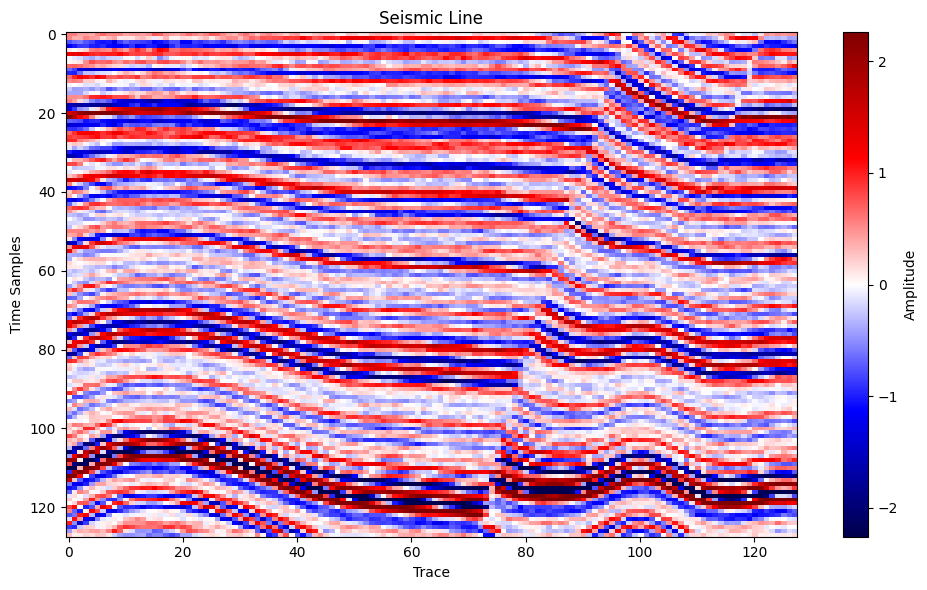

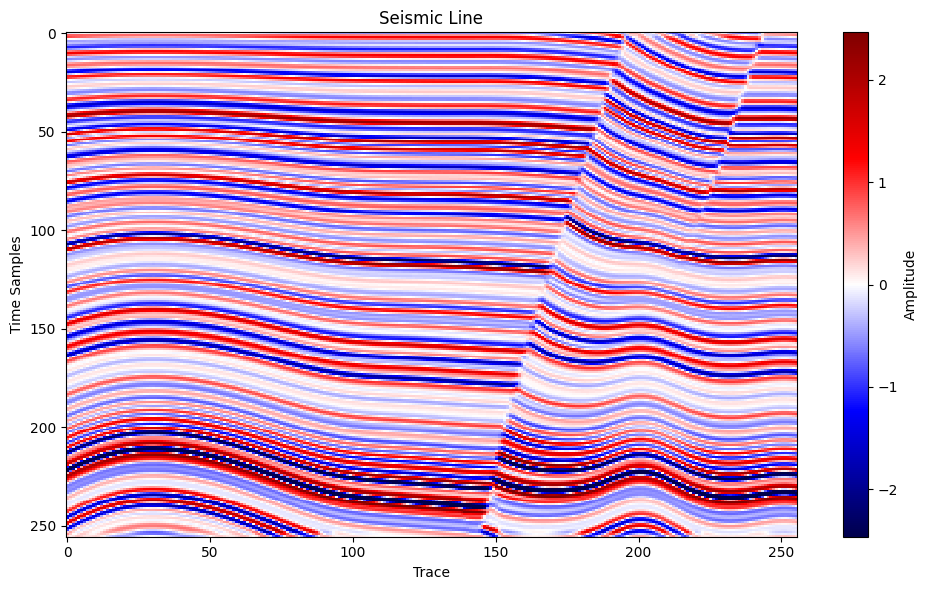

In [4]:
total_samples = 10000
random_index = random.randint(0, total_samples - 1)
plot_2D_seismic(low_resolution[random_index,:,:])
plot_2D_seismic(high_resolution[random_index,:,:])

# Foward Process


In [5]:
num_timesteps=1000
Noise_schedule = build_noise_schedule(num_timesteps, device=device)

In [6]:
# # batch = next(iter(train_dataloader))
# show_noisy_seismic_cubes([[get_noisy_seismic(high_resolution[0].T,schedule= Noise_schedule, t = torch.tensor([t])) for t in [0,
#                                                                                               100,
#                                                                                               200,
#                                                                                               300,
#                                                                                               400,
#                                                                                               500,
#                                                                                               600,
#                                                                                               700,
#                                                                                               800,
#                                                                                               900,
#                                                                                               999]]])

# Train process

In [7]:
from torch.optim import Adam


model = DiffusionFNOUnet(dim=12, cond_cha=1, channels=1, output_dim=2, dim_mults=( 4, 8, 16, 32)).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)

In [8]:
def count_params(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



print(f"Model parameters: {count_params(model):,}")

Model parameters: 492,361,538


In [9]:
# Your data
X = high_resolution
Y = low_resolution
dataset = TensorDataset(X, Y)

# Sizes
total_size = len(dataset)
test_size = int(0.10 * total_size)
remaining_size = total_size - test_size
train_size = int(0.90 * remaining_size)
val_size = remaining_size - train_size

# Splits
train_val_dataset, test_dataset = random_split(dataset, [remaining_size, test_size],generator=torch.Generator().manual_seed(42))
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size],generator=torch.Generator().manual_seed(42))

# Loaders
batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Info
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 8100
Validation dataset size: 900
Test dataset size: 1000


In [ ]:
epochs = 150
patience = 50  # number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    val_epoch_loss = 0

    # ===== Training =====
    model.train()
    for x, cond in train_loader:
        x, cond = x.to(device).unsqueeze(0).float(), cond.to(device).unsqueeze(0).float()
        t = torch.randint(1, num_timesteps, (x.shape[0],), device=device).long()

        loss = compute_loss(model, x, cond, t, Noise_schedule, device=device)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_train_loss = epoch_loss / len(train_loader)
    train_loss_per_epoch.append(avg_epoch_train_loss)

    # ===== Validation =====
    model.eval()
    with torch.no_grad():
        for x_val, cond_val in val_loader:
            x_val, cond_val = x_val.unsqueeze(0).to(device).float(), cond_val.unsqueeze(0).to(device).float()
            t_val = torch.randint(1, num_timesteps, (x_val.shape[0],), device=device).long()

            val_loss = compute_loss(model, x_val, cond_val, t_val, Noise_schedule, device=device)
            val_epoch_loss += val_loss.item()

        avg_epoch_val_loss = val_epoch_loss / len(val_loader)
        val_loss_per_epoch.append(avg_epoch_val_loss)

    end_time = time.time()
    epoch_duration = end_time - start_time
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_epoch_train_loss:.6f} - "
          f"Validation Loss: {avg_epoch_val_loss:.6f} - Time: {epoch_duration:.2f}s")

    # ===== Image Sampling (Optional) =====
    if epoch % 10 == 0 or epoch == epochs - 1:
        with torch.no_grad():
            cond_sample = next(iter(val_loader))[1].to(device).float().unsqueeze(0)
            sample_images = ddim_sample_conditional(
                model, image_size=(1,256, 256),
                num_timesteps=num_timesteps,
                betas=cosine_schedule(num_timesteps),
                cond=cond_sample, batch_size=1, device=device
            )
            plot_2D_seismic(sample_images[0, :, :].cpu().numpy())
            plot_2D_seismic(cond_sample[0, :, :].cpu().numpy())

    # ===== Early Stopping =====
    if avg_epoch_val_loss < best_val_loss:
        best_val_loss = avg_epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), '/home/g202393750/Documents/Superresolution/The definitive model/models/best_model_SeisDiffFNO_weights_standireze_ConelfavordeDios.pth')
        print("✨ Validation loss improved — model saved!")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve}/{patience} epochs.")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered! Training stopped.")
        break

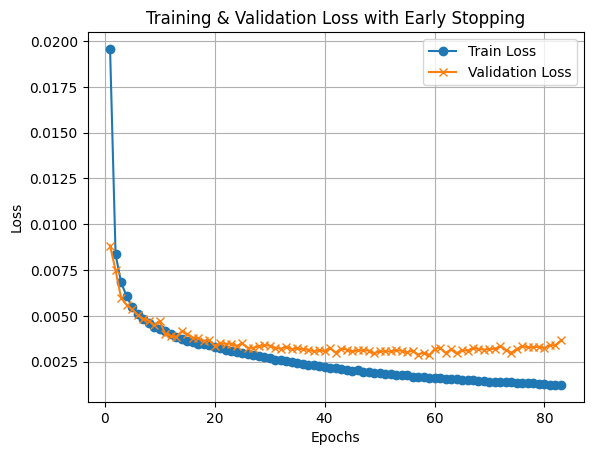

In [14]:
# ===== Final Plots =====
plt.plot(range(1, len(train_loss_per_epoch)+1), train_loss_per_epoch, marker='o', label='Train Loss')
plt.plot(range(1, len(val_loss_per_epoch)+1), val_loss_per_epoch, marker='x', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss with Early Stopping")
plt.legend()
plt.grid()
plt.savefig('/home/g202393750/Documents/Superresolution/The definitive model/Figs/Loss/Loss_SeisdiffFNO_2D_with_standirize_ConelfavordeDios.png', dpi=300)
plt.show()

In [11]:
train_loss = np.array(train_loss_per_epoch)
np.save('/home/g202393750/Documents/Superresolution/The definitive model/Training/History/train_loss-SeisDiffFNO_3.npy',train_loss)

In [12]:
val_loss = np.array(val_loss_per_epoch)
np.save('/home/g202393750/Documents/Superresolution/The definitive model/Training/History/val_loss-SeisDiffFNO_3.npy',val_loss)

In [13]:
torch.save(model.state_dict(), '/home/g202393750/Documents/Superresolution/The definitive model/models/last_model_SeisDiffFNO_weights_standirezeFNO_ConelfavordeDios.pth')

torch.Size([1, 1, 128, 128])


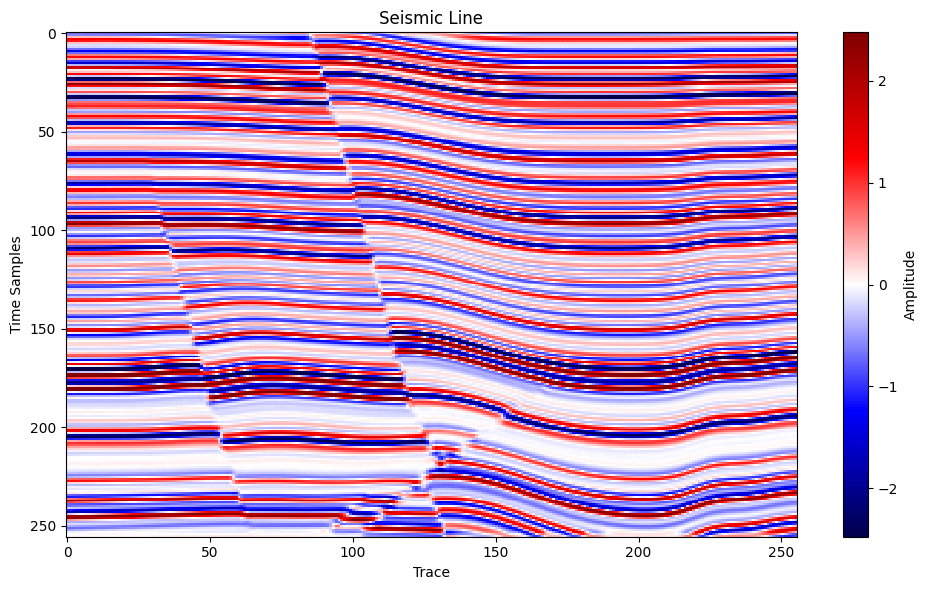

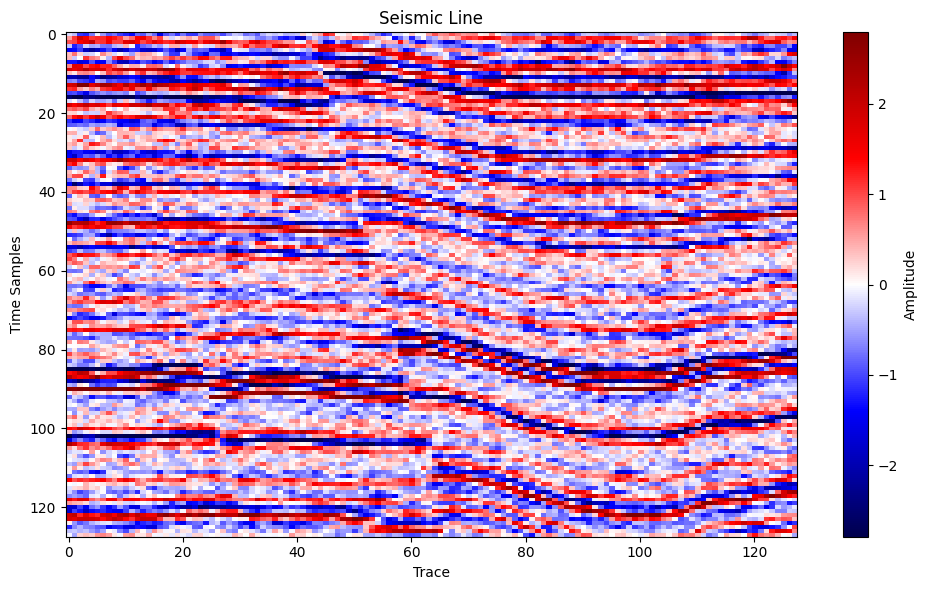

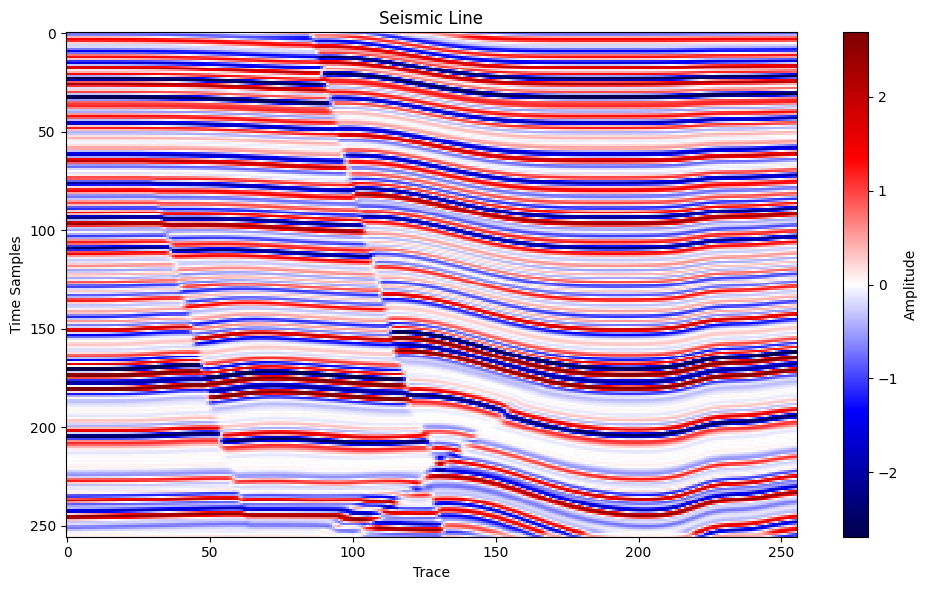

In [15]:
import itertools

# get the nth batch directly, e.g., n=5
n = 50
x_test, cond_test = next(itertools.islice(test_loader, n, None))
x_test, cond_test = x_test.to(device), cond_test.unsqueeze(0).to(device)
x_test = x_test.float()
cond_test = cond_test.float()
print(cond_test.shape)

sample_images =  ddpm_sample_conditional_xct(
            model,
            image_size=(1, cond.shape[2]*2, cond.shape[3]*2),
            num_timesteps=num_timesteps,
            betas = cosine_schedule(num_timesteps),
            cond=cond_test,
            batch_size=1,
            device=device)
plot_2D_seismic(sample_images[0,:,:].cpu().numpy())
plot_2D_seismic(cond_test[0,:,:].cpu().numpy())
plot_2D_seismic(x_test[0,:,:].cpu().numpy())

In [18]:
from eva_metrics import *

label = x_test[0,:,:].cpu().numpy()
output_data_FNO = sample_images[0,0,:,:].cpu().numpy()



mse_1_FNO = mse_cal(label, output_data_FNO)
snr_1_FNO, psnr_1_FNO = calculate_snr_psnr(label, output_data_FNO)
ssim_1_FNO = compute_2d_ssim(label, output_data_FNO)
fd_1_FNO = FrechetDistances(label,output_data_FNO)



print(f'MSE recon SeisDiffFNO: {mse_1_FNO:.3f} ')
print(f'SNR recon SeisDiffFNO: {snr_1_FNO:.3f} dB ')
print(f'PSNR recon SeisDiffFNO: {psnr_1_FNO:.3f} dB ')
print(f'SSIM recon SeisDiffFNO: {ssim_1_FNO:.3f}')
print(f'FD recon SeisDiffFNO: {fd_1_FNO:.3f} ')

MSE recon SeisDiffFNO: 0.012 
SNR recon SeisDiffFNO: 19.269 dB 
PSNR recon SeisDiffFNO: 35.638 dB 
SSIM recon SeisDiffFNO: 0.976
FD recon SeisDiffFNO: 0.065 
